In [1]:
using Plots                          # Plotting
using CSV, DataFrames, JLD2          # Data handling
using LinearAlgebra, StatsBase       # Linear algebra, statistics
using Random, Statistics             # Random number generation, basic statistics
using LaTeXStrings                   # LaTeX support for plots
using Revise                          # Live code reloading

using StaticArrays, LazySets          # Efficient arrays, set operations
using Interpolations, LinearInterpolations  # Interpolation utilities
using SpatiotemporalGPs               # Gaussian processes
using DifferentialEquations, ForwardDiff # Differential equations, automatic differentiation


In [2]:
# Import modules
include("../src/jordan_lake_domain.jl")
# include("../src/stgpkf.jl")
include("../src/kf.jl")
include("../src/ngpkf.jl")
include("../src/SyntheticData.jl")
include("../src/ergodic.jl")
include("../src/variograms.jl")
include("../src/SOC_Controller.jl")
include("../src/simulator_spatial.jl")
include("../src/simulator_ST.jl")
include("../src/Convex_bound_avoidance.jl")

┌ Warning: Replacing docs for `Main.Variograms.hp_fit :: Tuple{Any}` in module `Main.Variograms`
└ @ Base.Docs docs/Docs.jl:243


Main.ConvexBoundAvoidance

# Load JLD files

In [3]:
# Load the JLD2 file
file_path = "20241115_ergodic.jld2"
f = jldopen(file_path, "r")
res_ergo_hp = f["res_ergo_hp"]
synthetic_data = f["synthetic_data"]
soc_target = f["soc_target"]
ts_hrs = f["ts_hrs"]
close(f)

In [4]:
fields = fieldnames(typeof(res_ergo_hp))
println(fields)

(:ts, :xs, :us, :speeds, :bs, :measurements, :w_hat_ts, :w_hats, :ergo_q_maps, :q_target_maps)


# Common Variables

In [6]:
polygon_vertices = hcat(JordanLakeDomain.convex_polygon.vertices, JordanLakeDomain.convex_polygon.vertices[:, 1])  # Close the polygon
fuse_measurements_every_ΔT = 5.0/(60) # hours
recompute_controller_every_ΔT = 5.0 / (120.0*60) # minutes
σ_t = zeros(66, 15);
w_rated_val = -0.5;

┌ Info: Saved animation to /home/kmgovind/research/adaptive-ocean-exploration-sim/lakedata_sim/path_over_real_wind.gif
└ @ Plots /home/kmgovind/.julia/packages/Plots/Ec1L1/src/animation.jl:156


Plots.AnimatedGif("/home/kmgovind/research/adaptive-ocean-exploration-sim/lakedata_sim/path_over_real_wind.gif")
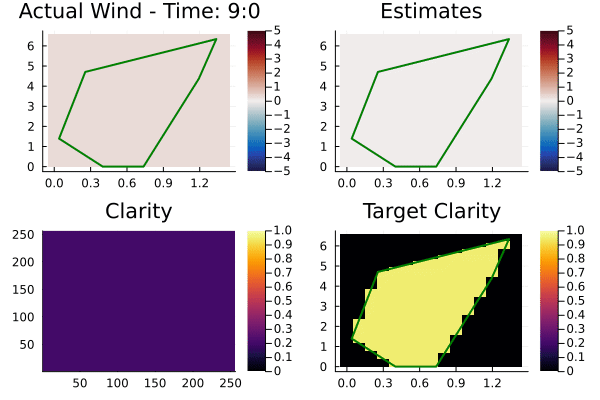

In [7]:
path_over_real_wind = @animate for n = 1:50:length(res_ergo_hp.ts)
    # Plot the actual wind and path
    plot()
    heatmap(synthetic_data.xs, synthetic_data.ys, synthetic_data.data[:,:,n]', cmap = :balance; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    # for i=1:size(res_ergo_hp.xs)[1]
    #     x = [r[i][1] for r in res_ergo_hp.xs[1:n]]
    #     y = [r[i][2] for r in res_ergo_hp.xs[1:n]]
    #     plot!(x, y, linewidth=3, color=:black, label="w_rated_val = $(w_rated_val)")
    # end
    title!("Actual Wind - Time: $(Int(floor(ts_hrs[n]))):$(Int(floor(mod(ts_hrs[n],1)*60)))")
    real_wind = plot!(clims=(-5.0,5.0))

    # Plot the KF estimates
    plot()
    if res_ergo_hp.ts[n] in res_ergo_hp.w_hat_ts
        global w_hat_idx = findfirst(isequal(res_ergo_hp.ts[n]), res_ergo_hp.w_hat_ts)
    end
    heatmap(synthetic_data.xs, synthetic_data.ys, res_ergo_hp.w_hats[w_hat_idx]', cmap=:balance)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(-5.0,5.0))
    title!("Estimates")
    estimate_wind = plot!()

    # Plot the clarity map
    # claritymap = heatmap(synthetic_data.xs, synthetic_data.ys, res_ergo_hp.ergo_q_maps[w_hat_idx]')
    claritymap = heatmap(res_ergo_hp.ergo_q_maps[w_hat_idx]')
    # plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    plot!(clims=(0.0,1.0))
    title!("Clarity")
    claritymap = plot!()

    # Plot the target clarity map
    plot()
    heatmap(synthetic_data.xs, synthetic_data.ys, res_ergo_hp.q_target_maps[n]'; plottype=:wx)
    plot!(polygon_vertices[1, :], polygon_vertices[2, :], seriestype=:shape, fillalpha=0.0, label="", lw = 2, linecolor = "green")
    title!("Target Clarity")
    target_clarity = plot!(clims=(0.0, 1.0))

    plot(real_wind, estimate_wind, claritymap, target_clarity, layout=(2,2))
    
end
gif(path_over_real_wind, "path_over_real_wind.gif")

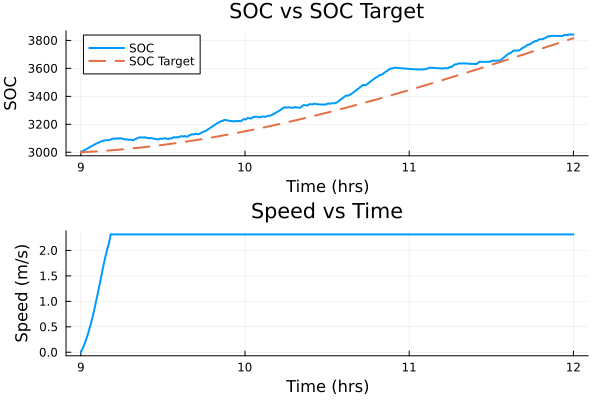

In [8]:
# Extract SOC data
soc_data = res_ergo_hp.bs

# Plot SOC data against SOC target
plot(ts_hrs, soc_data[2:end], label="SOC", xlabel="Time (hrs)", ylabel="SOC", lw=2)
plot!(ts_hrs, soc_target, label="SOC Target", lw=2, linestyle=:dash)
title!("SOC vs SOC Target")
soc_plot = plot!()

# Plot the speed vs Time
speed_plot = plot(ts_hrs, res_ergo_hp.speeds, label=false, xlabel="Time (hrs)", ylabel="Speed (m/s)", title="Speed vs Time", lw=2)

# Coplot
plot(soc_plot, speed_plot, layout=(2,1))